In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [89]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import files

In [49]:
data_path = "/content/drive/MyDrive/Colab Notebooks/Disease Prediction/H.csv"
df = pd.read_csv(data_path)
df.head()

,Patient_Age,Gender,Chest_Pain_Type,Resting_Blood_Pressure,Serum_Cholestoral,Fasting_Blood_Sugar,Resting_Electrocardiographic,Maximum_Heart_Rate,Exercise_Induced_Angina,ST_depression_induced_exercise,Slope_peak_exercise,Major_vessels_colored,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Here is the concise data dictionary for the columns in your heart disease dataset:

    Patient_Age: The age of the patient in years.

    Gender: The biological sex of the patient, where 1 represents male and 0 represents female.

    Chest_Pain_Type: The type of chest pain experienced, categorized from 0 to 3 (typical angina, atypical angina, non-anginal pain, asymptomatic).

    Resting_Blood_Pressure: The patient's resting blood pressure measured in mm Hg upon admission to the hospital.

    Serum_Cholestoral: The patient's cholesterol measurement in mg/dl.

    Fasting_Blood_Sugar: Indicates if fasting blood sugar is greater than 120 mg/dl (1 = true; 0 = false).

    Resting_Electrocardiographic: Resting electrocardiogram results categorized from 0 to 2 (normal, ST-T wave abnormality, left ventricular hypertrophy).

    Maximum_Heart_Rate: The highest heart rate achieved by the patient during an exercise stress test.

    Exercise_Induced_Angina: Indicates whether exercise induced an episode of chest pain (1 = yes; 0 = no).

    ST_depression_induced_exercise: Numerical value measuring electrocardiogram ST segment depression induced by exercise relative to rest.

    Slope_peak_exercise: The slope of the peak exercise ST segment, categorized from 0 to 2 (upsloping, flat, downsloping).

    Major_vessels_colored: The number of major blood vessels (0–4) visible under a fluoroscopy X-ray.

    thal: A blood disorder feature representing thalassemia types (1 = fixed defect; 2 = normal; 3 = reversible defect).

    target: The classification label indicating the presence of heart disease (1 = heart disease present; 0 = healthy).

#**Data Cleaning**

In [50]:
from IPython.core.interactiveshell import removed_co_newlocals
#Structural Integrity Audit
print("DataSet Shape")
rows, cols = df.shape
print(f"Total Patients Records = {rows}")
print(f"Total Clinical Features = {cols}")

print("="*40)
print("Columns Data Types and Non_Null counts")
print("="*40)
df.info()

print("="*40)
print("Whitspaces and Anomoly Audit")
print("="*40)
white_spaces_issues = 0
for col in df.columns:
  if col.strip() !=col:
    print(f"Warning: Column {col} contain hidden leading/tainling whitespace")
    white_spaces_issues += 1

if white_spaces_issues == 0 :
  print("No WhiteSpaces")
else:
  print(f"Total issues found = {white_spaces_issues}")



DataSet Shape
Total Patients Records = 303
Total Clinical Features = 14
Columns Data Types and Non_Null counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Patient_Age                     303 non-null    int64  
 1   Gender                          303 non-null    int64  
 2   Chest_Pain_Type                 303 non-null    int64  
 3   Resting_Blood_Pressure          303 non-null    int64  
 4   Serum_Cholestoral               303 non-null    int64  
 5   Fasting_Blood_Sugar             303 non-null    int64  
 6   Resting_Electrocardiographic    303 non-null    int64  
 7   Maximum_Heart_Rate              303 non-null    int64  
 8   Exercise_Induced_Angina         303 non-null    int64  
 9   ST_depression_induced_exercise  303 non-null    float64
 10  Slope_peak_exercise             303 non-null   

In [51]:
print("Check Duplication")
duplicated_count = df.duplicated().sum()
print("="*40)
print("Start Duplication Audit")
print("="*40)
print(f"Total duplicate rows detected: {duplicated_count}")
print("="*40)

if duplicated_count > 0:
  print("Displaying Duplicated Rows")
  pd.set_option("display.max_columns",None) # forcing pandas to show all columns
  display(df[df.duplicated(keep=False)])


if duplicated_count > 0 :
  df = df.drop_duplicates()
else:
  print("No Duplicates Found")
print(f"New Dataset Shape : {df.shape[0]} rows, {df.shape[1]} columns ")

Check Duplication
Start Duplication Audit
Total duplicate rows detected: 1
Displaying Duplicated Rows


,Patient_Age,Gender,Chest_Pain_Type,Resting_Blood_Pressure,Serum_Cholestoral,Fasting_Blood_Sugar,Resting_Electrocardiographic,Maximum_Heart_Rate,Exercise_Induced_Angina,ST_depression_induced_exercise,Slope_peak_exercise,Major_vessels_colored,thal,target
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


New Dataset Shape : 302 rows, 14 columns 


In [52]:
print("Check Missing Values")
print("="*40)
standard_missing = df.isnull().sum()
#Check for common hidden placeholders in object/string columns
question_marks = (df == '?').sum()
empty_strings = (df == ' ').sum()
#Check for invalid placeholder flags (like -1) in strictly positive columns
# (Age, Blood Pressure, and Cholesterol cannot logically be negative or zero)
negative_ones = (df[['Patient_Age', 'Resting_Blood_Pressure', 'Serum_Cholestoral']] == -1).sum()

missing_summary = pd.DataFrame({
    'Standard Nan':standard_missing,
    "Hidden":question_marks,
    "Hidden Spaces":empty_strings
})

#Add another column
missing_summary['-1 Flags'] = 0
for col in negative_ones.index:
    missing_summary.loc[col, '-1 Flags'] = negative_ones[col]
print("Summary of Missing Values and Placeholders per Column:")
print(missing_summary)
print("-" * 40)

Check Missing Values
Summary of Missing Values and Placeholders per Column:
                                Standard Nan  Hidden  Hidden Spaces  -1 Flags
Patient_Age                                0       0              0         0
Gender                                     0       0              0         0
Chest_Pain_Type                            0       0              0         0
Resting_Blood_Pressure                     0       0              0         0
Serum_Cholestoral                          0       0              0         0
Fasting_Blood_Sugar                        0       0              0         0
Resting_Electrocardiographic               0       0              0         0
Maximum_Heart_Rate                         0       0              0         0
Exercise_Induced_Angina                    0       0              0         0
ST_depression_induced_exercise             0       0              0         0
Slope_peak_exercise                        0       0              

#Detect Outliers
use Interquartile Range ($IQR$) because

It is Robust to Skewed Distributions (Non-Parametric)

It Protects Against the "Masking Effect"

**Explain why we did use set here insted of list**

In [55]:
print("Check Outlier")
# Define the continuous numerical features to inspect
continuous_features = ['Resting_Blood_Pressure', 'Serum_Cholestoral', 'Maximum_Heart_Rate', 'ST_depression_induced_exercise']
outlier_indices = set()

for col in continuous_features :
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  column_outliers = df[(df[col] < lower_bound) | (df[col]> upper_bound)]
  num_outliers = len(column_outliers)
  print(f"   Middle 50% Range (IQR): {Q1} to {Q3}")
  print(f"   Statistical Normal Boundaries: {lower_bound:.2f} to {upper_bound:.2f}")
  print(f"   Outliers Detected: {num_outliers} row(s)")
  if num_outliers > 0:
        print(f"   Outlier values present: {column_outliers[col].values.tolist()}")
        outlier_indices.update(column_outliers.index)
  print("=" * 40)

total_outlier_rows = len(outlier_indices)
print(f"Total unique patient records containing at least one statistical outlier: {total_outlier_rows}")
print("=" * 40)


Check Outlier
   Middle 50% Range (IQR): 120.0 to 140.0
   Statistical Normal Boundaries: 90.00 to 170.00
   Outliers Detected: 9 row(s)
   Outlier values present: [172, 178, 180, 180, 200, 174, 192, 178, 180]
   Middle 50% Range (IQR): 211.0 to 274.75
   Statistical Normal Boundaries: 115.38 to 370.38
   Outliers Detected: 5 row(s)
   Outlier values present: [417, 564, 394, 407, 409]
   Middle 50% Range (IQR): 133.25 to 166.0
   Statistical Normal Boundaries: 84.12 to 215.12
   Outliers Detected: 1 row(s)
   Outlier values present: [71]
   Middle 50% Range (IQR): 0.0 to 1.6
   Statistical Normal Boundaries: -2.40 to 4.00
   Outliers Detected: 5 row(s)
   Outlier values present: [4.2, 6.2, 5.6, 4.2, 4.4]
Total unique patient records containing at least one statistical outlier: 19


##**a deep dive into the medical reality of these numbers proves that they are genuine, high-risk clinical profiles, not errors.**

#**EDA**

In [59]:
print("Satarting EDA")
print("="*40)
print("Target Calss Balanace Analysis")
target_counts = df['target'].value_counts()
target_percentage = df['target'].value_counts(normalize=True)*100
print("Target Distribution")
for status, count in target_counts.items():
  label = "Heart Disease (1) =" if status ==1 else "Healthy (0) = "
  pct = target_percentage[status]
  print(f"{label} {count} ({pct:.2f}%)")


Satarting EDA
Target Calss Balanace Analysis
Target Distribution
Heart Disease (1) = 164 (54.30%)
Healthy (0) =  138 (45.70%)


##No Imbalance Handling Needed: You do not need to use complex sampling algorithms like

##Standard Evaluation Metrics Work Perfectly: You will be able to trust standard evaluation metrics like Accuracy, Precision, Recall, and F1-Score completely when evaluating your models later.


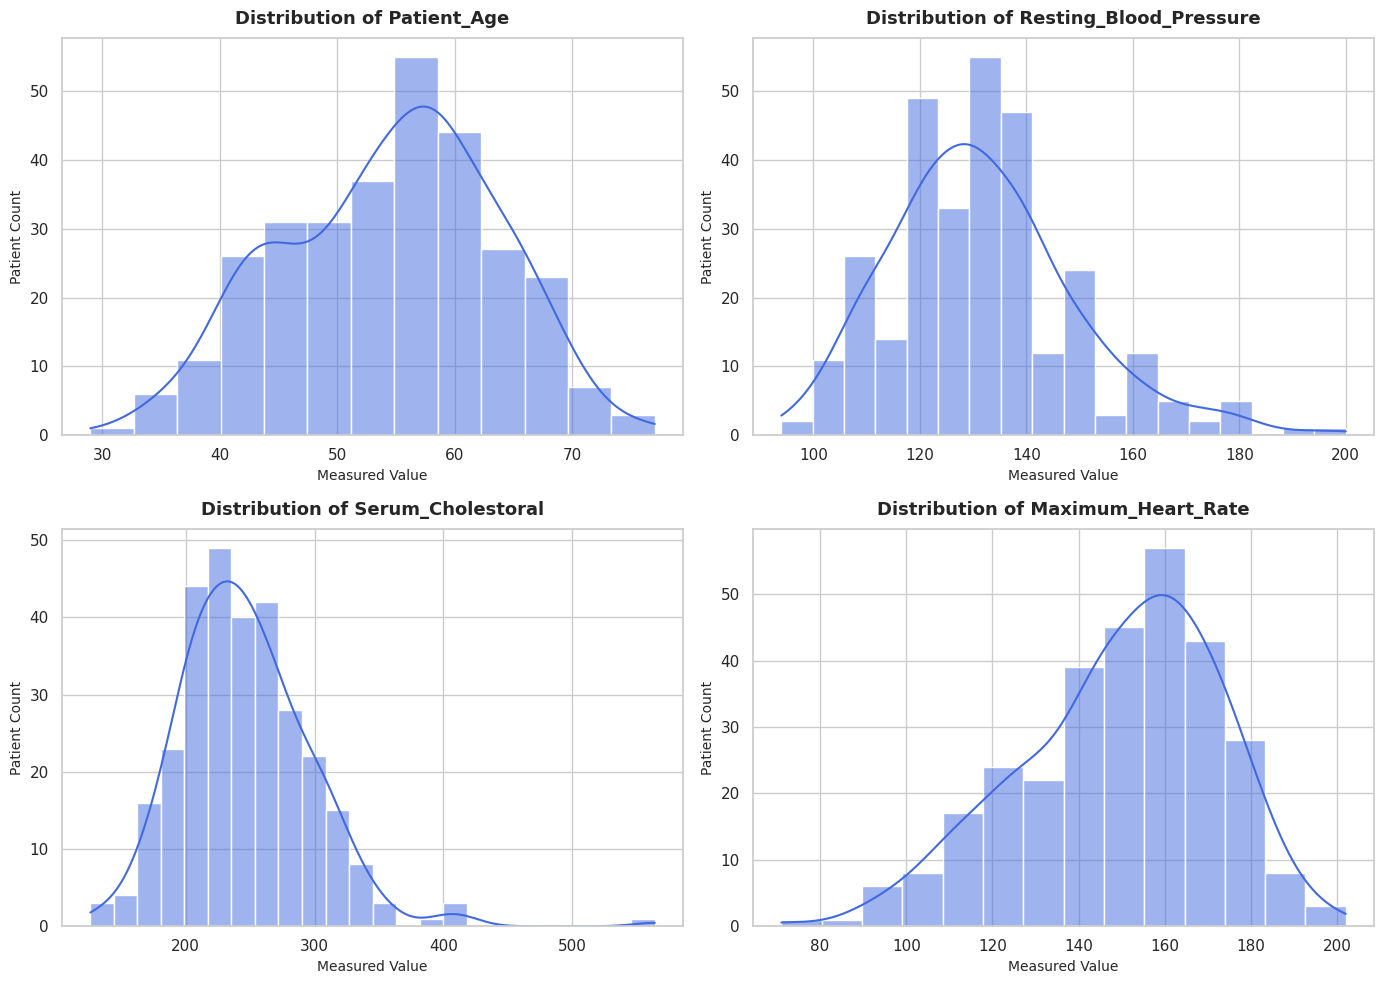

In [60]:
#distribution profiling "Univariant Analysis"

#set clean visual theme
sns.set_theme(style="whitegrid")
#define continous features
continuous_features = ['Patient_Age','Resting_Blood_Pressure','Serum_Cholestoral','Maximum_Heart_Rate']
fig,axes = plt.subplots(2,2,figsize=(14,10))
axes = axes.flatten()
for i,col in enumerate(continuous_features):
  sns.histplot(data= df,x=col,kde=True,ax=axes[i],color='royalblue',edgecolor='white')
  axes[i].set_title(f"Distribution of {col}",fontsize=13,fontweight='bold',pad=10)
  axes[i].set_xlabel("Measured Value",fontsize=10)
  axes[i].set_ylabel("Patient Count",fontsize=10)

plt.tight_layout()
plt.show()

Because your features don't all share the same ranges (e.g., Cholesterol goes up to 564, while Age stops at 77), feeding these raw distributions directly into distance-based machine learning algorithms (like Logistic Regression, KNN, or SVM) will cause the model to ignore Age and fixate entirely on Cholesterol.

Calculate Clinical Risk Correlation Matrix


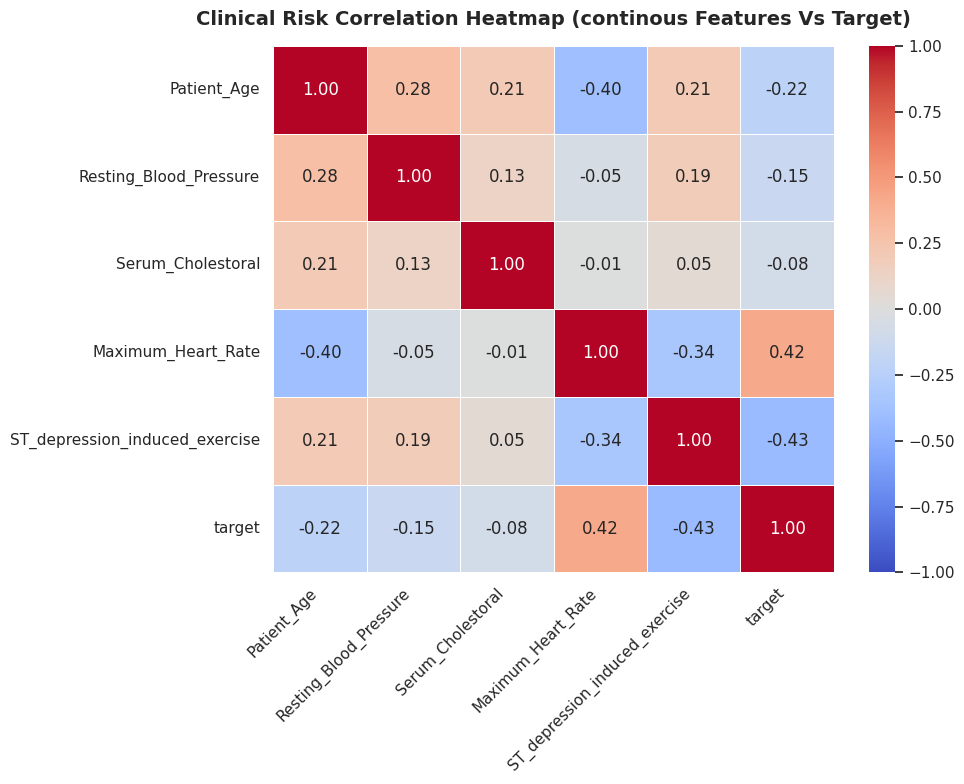

In [63]:
#Clinical Risk Correlation (Bivariate Analysis)
print("Calculate Clinical Risk Correlation Matrix")
correlation_features = ['Patient_Age', 'Resting_Blood_Pressure', 'Serum_Cholestoral',
                        'Maximum_Heart_Rate', 'ST_depression_induced_exercise', 'target']
corr_matrix = df[correlation_features].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Clinical Risk Correlation Heatmap (continous Features Vs Target)",fontsize=14,fontweight='bold',pad=15 )
plt.xticks(rotation=45,ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

The reason we only chose those specific features comes down to a fundamental rule of statistics: Pearson's Correlation Coefficient ($r$) only works on truly continuous numerical data.

**Don't Forget to add  explantion of those values**

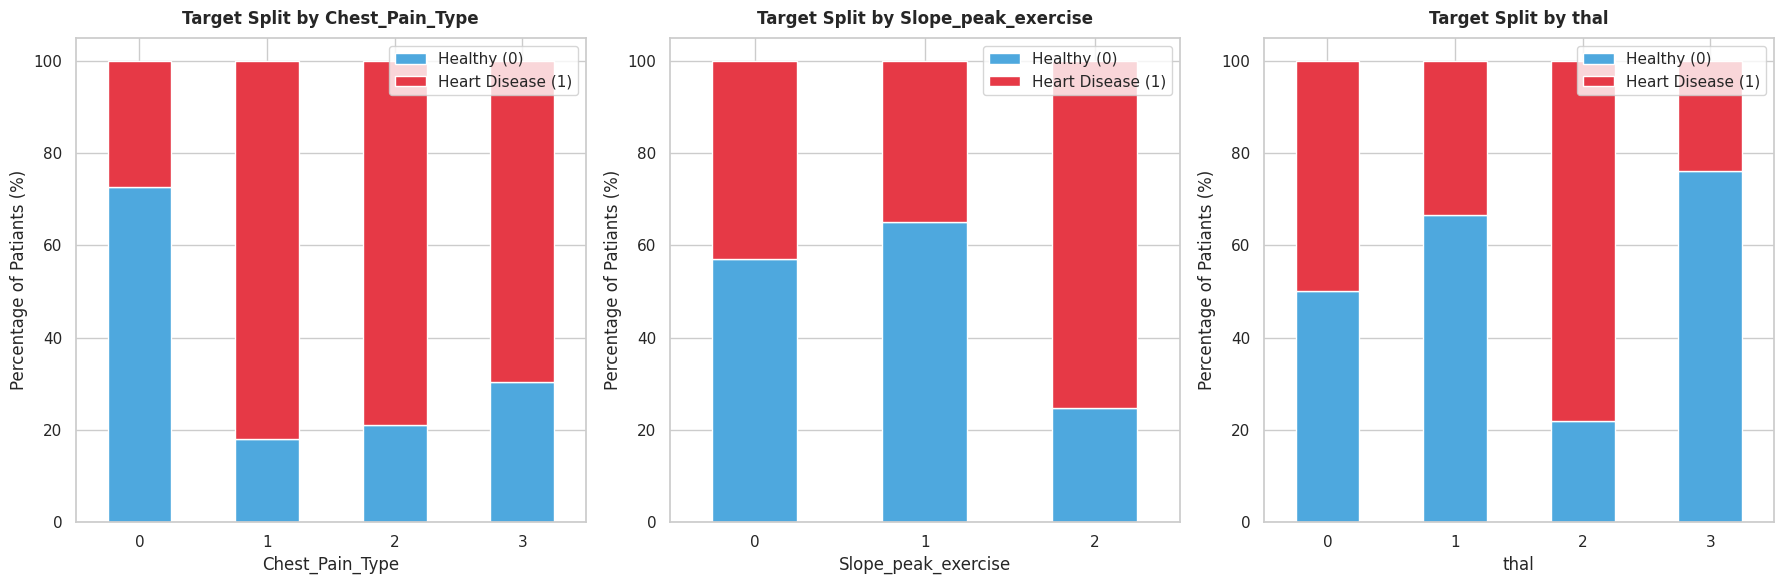

In [69]:
#GENERATING CATEGORICAL STRATIFICATION CHARTS
categorical_features = ['Chest_Pain_Type',"Slope_peak_exercise",'thal']
fig,axes = plt.subplots(1,3,figsize=(18,6))
axes = axes.flatten()

#Loop through Each Categorical feature
for i,col in enumerate(categorical_features):
  crosstab_pct = pd.crosstab(df[col],df['target'], normalize='index')*100
  crosstab_pct.plot(kind='bar', stacked=True, color=['#4ea8de', '#e63946'], ax=axes[i], edgecolor='white')
  axes[i].set_title(f"Target Split by {col}",fontsize=12,fontweight='bold',pad=10)
  axes[i].set_xlabel=("Category Code")
  axes[i].set_ylabel('Percentage of Patiants (%)')
  axes[i].legend(['Healthy (0)','Heart Disease (1)'],loc='upper right')
  axes[i].tick_params(axis='x',rotation=0)

plt.tight_layout()
plt.show()

The Pearson correlation matrix you just ran has one strict rule: it requires a continuous, mathematical scale where numbers mean "more" or "less" of a physical quantity.

**How the New Analysis (Category Stratification) Helps**

Since we cannot use a linear correlation matrix on categories, we switch to Category Stratification. This means we split (stratify) our patient data into groups based on their categories, and then look at how the target diagnosis is distributed within each group.

**No data modifications or fixes are needed. Sometimes when people see such a stark contrast, they worry that the data is "too perfect" or that they need to balance the sub-categories. You don't! This clean separation is exactly what you are looking for in Exploratory Data Analysis. It confirms that you have incredibly strong signals in your categorical features, meaning tree-based algorithms like Random Forest or Gradient Boosting are going to perform phenomenally well on this data.**


#**Feature Engineering & Transformation**

In [77]:
#TARTING EXPLICIT CATEGORICAL REMAPPING
chest_pain_map = {
    0: 'Typical Angina',
    1: 'Atypical Angina',
    2: 'Non-anginal Pain',
    3: 'Asymptomatic'
}

slope_map = {
    0: 'Upsloping',
    1: 'Flat',
    2: 'Downsloping'
}

thal_map = {
    0: 'Unknown/Null',
    1: 'Normal',
    2: 'Fixed Defect',
    3: 'Reversible Defect'
}
df_mapped = df.copy()
df_mapped['Chest_Pain_Type'] = df_mapped['Chest_Pain_Type'].map(chest_pain_map)
df_mapped['Slope_peak_exercise'] = df_mapped['Slope_peak_exercise'].map(slope_map)
df_mapped['thal'] = df_mapped['thal'].map(thal_map)

print("Success: Categorical variables mapped to descriptive text strings")
print("Quick Sample of Remapped Data Fields")
print(df_mapped[['Chest_Pain_Type','Slope_peak_exercise','thal']].head())


Success: Categorical variables mapped to descriptive text strings
Quick Sample of Remapped Data Fields
    Chest_Pain_Type Slope_peak_exercise          thal
0      Asymptomatic           Upsloping        Normal
1  Non-anginal Pain           Upsloping  Fixed Defect
2   Atypical Angina         Downsloping  Fixed Defect
3   Atypical Angina         Downsloping  Fixed Defect
4    Typical Angina         Downsloping  Fixed Defect


Right now, your categorical columns like Chest_Pain_Type and thal contain numeric integers ($0, 1, 2, 3$). If you jump straight to automated one-hot encoding methods (like using pd.get_dummies(df)), pandas has no way of knowing that those columns are actually text-based categories. It will treat them as numbers, skip them entirely, or output messy column headers like Chest_Pain_Type_0, Chest_Pain_Type_1, etc.

In [79]:
#EXECUTING ONE-HOT DUMMY EXPLOSION
columns_to_encode = ['Chest_Pain_Type', 'Slope_peak_exercise', 'thal']
df_processed = pd.get_dummies(
    df_mapped,
    columns=columns_to_encode,
    drop_first = True,
    dtype=int
)
print("Catogrical text strings explode into distinct binary indicator")
print(f'orgiginal dataframe shape : {df_mapped.shape}')
print(f"Post-Explosion DataFrame shape : {df_processed.shape}")
print("New Feature Inventory (First 15 columns shown):")
for col in list(df_processed.columns)[:15]:
    print(f" - {col}")


Catogrical text strings explode into distinct binary indicator
orgiginal dataframe shape : (302, 14)
Post-Explosion DataFrame shape : (302, 19)
New Feature Inventory (First 15 columns shown):
 - Patient_Age
 - Gender
 - Resting_Blood_Pressure
 - Serum_Cholestoral
 - Fasting_Blood_Sugar
 - Resting_Electrocardiographic
 - Maximum_Heart_Rate
 - Exercise_Induced_Angina
 - ST_depression_induced_exercise
 - Major_vessels_colored
 - target
 - Chest_Pain_Type_Atypical Angina
 - Chest_Pain_Type_Non-anginal Pain
 - Chest_Pain_Type_Typical Angina
 - Slope_peak_exercise_Flat


### 📝 Note on One-Hot Encoding & The Baseline Reference Group

When exploding our categorical text features into binary indicators, we explicitly set `drop_first=True`. This drops one category from each feature to serve as our **Baseline Reference Group** and prevents **Multicollinearity** (the Dummy Variable Trap), which stabilizes our upcoming machine learning models.

#### How the Model Recovers the Dropped Data:
No information or rows are lost. The model uses pure logical and mathematical elimination to evaluate the dropped categories:

1. **Logical Elimination (Tree Models):** If a patient evaluates to `0` for all remaining dummy columns of a feature, the model logically concludes they belong to the dropped baseline category.
2. **Mathematical Absorption (Linear Models):** When all dummy columns for a feature collapse to `0`, their respective coefficients drop out of the risk equation. The model's **Intercept ($b$)** automatically absorbs and represents the exact weight and clinical risk of that dropped reference category.

#### Our Engineered Reference Baseline Map:
* **Dropped `Chest_Pain_Type_Typical Angina`** $\rightarrow$ Remaining columns calculate risk *relative* to a patient having Typical Angina.
* **Dropped `Slope_peak_exercise_Downsloping`** $\rightarrow$ Remaining columns calculate risk *relative* to a patient having a Downsloping ST segment.
* **Dropped `thal_Unknown/Null`** $\rightarrow$ Remaining columns calculate risk *relative* to this baseline state.

In [85]:
#Excuting Data Spliting & Variance Scaling
x = df_processed.drop(columns=['target'])
y = df_processed['target']

#excute train test split with 80% percent training and 20% tesiting
#stratify , to save same distribution balance between 0,1 on
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.20,stratify =y , random_state=42
)
scaler = StandardScaler()
continuous_features = ['Patient_Age', 'Resting_Blood_Pressure', 'Serum_Cholestoral',
                       'Maximum_Heart_Rate', 'ST_depression_induced_exercise']
x_train_scaled = x_train.copy()
x_test_scaled  = x_test.copy()

x_train_scaled[continuous_features] = scaler.fit_transform(x_train[continuous_features])
x_test_scaled[continuous_features] = scaler.transform(x_test[continuous_features])


Variance Scaling (Standardization) fixes this by converting every continuous measurement into a universal mathematical currency: Z-scores.


Before we run the code to scale your data, we must address an absolute golden rule of machine learning: We must split our dataset into Training (80%) and Testing (20%) data before we calculate any scaling factors.

If you calculate the average mean and standard deviation using the entire dataset, information from your test set will leak into your training process. This is a severe pipeline flaw called Data Leakage. It gives your model an artificial, cheating glimpse at data it shouldn't know about yet, leading to overly optimistic training metrics but terrible performance when deployed on real, unseen future patients.

In [90]:
#Save and export data
export_package = {
    'x_train_scaled.csv': x_train_scaled,
    'x_test_scaled.csv': x_test_scaled,
    'y_train.csv': y_train,
    'y_test.csv': y_test
}

for filename, dataset in export_package.items():
    dataset.to_csv(filename, index=False)
    print(f"Successfully exported: {filename} ({dataset.shape[0]} rows)")

files.download('x_train_scaled.csv')
files.download('x_test_scaled.csv')
files.download('y_train.csv')
files.download('y_test.csv')

Successfully exported: x_train_scaled.csv (241 rows)
Successfully exported: x_test_scaled.csv (61 rows)
Successfully exported: y_train.csv (241 rows)
Successfully exported: y_test.csv (61 rows)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>